In [1]:
!which pip

~/miniconda3/envs/autopath/bin/pip


In [32]:
!pip install einops

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 21.5 MB/s eta 0:00:00


In [33]:
from functools import partial
from importlib import reload
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import einops

from omegaconf import OmegaConf

In [3]:
HOME = os.environ['HOME']
DINOV2 = f"{HOME}/dinov2"
sys.path.insert(0, DINOV2)

# ImageNet: Setup

In [4]:
from dinov2.data.datasets import ImageNet
IMAGENET_ROOT = f"{HOME}/dinov2/data/imagenet/ILSVRC/Data/CLS-LOC"
ImageNet.Split.TRAIN

<_Split.TRAIN: 'train'>

# ImageNet: from `dinov2.train.train.do_train()`

In [6]:
from dinov2.data import (
    collate_data_and_cast, 
    DataAugmentationDINO, 
    MaskingGenerator,
    SamplerType, 
    make_dataset, 
    make_data_loader,
)

#from dinov2.train import get_args_parser

In [7]:
# adapted from dinov2.utils.config
cfg = OmegaConf.load(os.path.join(DINOV2, 'dinov2', 'configs', 'ssl_default_config.yaml'))

In [8]:
cfg.train.dataset_path

'ImageNet:split=TRAIN:root=/home/t-9dkarp/dinov2/data/imagenet/ILSVRC/Data/CLS-LOC:extra=/home/t-9dkarp/dinov2/data/imagenet/ILSVRC/Data/CLS-LOC'

In [9]:
# adapted from dinov2.train.tain.do_train()
data_transform = DataAugmentationDINO(
        cfg.crops.global_crops_scale,
        cfg.crops.local_crops_scale,
        cfg.crops.local_crops_number,
        global_crops_size=cfg.crops.global_crops_size,
        local_crops_size=cfg.crops.local_crops_size,
)

## dataset

In [10]:
dataset = make_dataset(
        dataset_str=cfg.train.dataset_path,
        transform=data_transform,
        target_transform=lambda _: (),
    )

In [58]:
ds0 = next(iter(dataset))

In [59]:
type(ds0)

tuple

In [62]:
display(type(ds0[0]))
display(ds0[0].keys())

dict

dict_keys(['global_crops', 'global_crops_teacher', 'local_crops', 'offsets'])

## dataloader

In [21]:
collate_fn = partial(
        collate_data_and_cast,
        mask_ratio_tuple=cfg.ibot.mask_ratio_min_max,
        mask_probability=cfg.ibot.mask_sample_probability,
        n_tokens=n_tokens,
        mask_generator=mask_generator,
        dtype=inputs_dtype,
    )

In [20]:
img_size = cfg.crops.global_crops_size
patch_size = cfg.student.patch_size
n_tokens = (img_size // patch_size) ** 2
inputs_dtype = torch.half
mask_generator = MaskingGenerator(
    input_size=(img_size // patch_size, img_size // patch_size),
    max_num_patches=0.5 * img_size // patch_size * img_size // patch_size,
)
start_iter = 0

In [22]:
sampler_type = SamplerType.SHARDED_INFINITE
data_loader = make_data_loader(
    dataset=dataset,
    batch_size=cfg.train.batch_size_per_gpu,
    num_workers=cfg.train.num_workers,
    shuffle=True,
    seed=start_iter,  # TODO: Fix this -- cfg.train.seed
    sampler_type=sampler_type,
    sampler_advance=0,  # TODO(qas): fix this -- start_iter * cfg.train.batch_size_per_gpu,
    drop_last=True,
    collate_fn=collate_fn,
)

In [23]:
dl0 = next(iter(data_loader))

In [24]:
type(dl0)

dict

In [25]:
dl0.keys()

dict_keys(['collated_global_crops', 'collated_local_crops', 'collated_masks', 'mask_indices_list', 'masks_weight', 'upperbound', 'n_masked_patches'])

In [50]:
def unnorm(_gc):
    return ((_gc-_gc.min())/(_gc.max()-_gc.min())*255).byte()

In [54]:
gc = unnorm(dl0['collated_global_crops'])
lc = unnorm(dl0['collated_local_crops'])

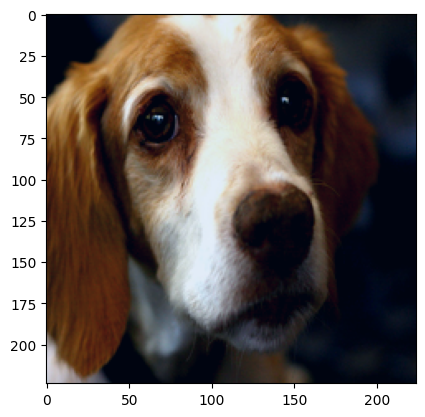

In [53]:
%matplotlib inline
plt.imshow(einops.rearrange(gc[1,...], 'c h w -> h w c'))

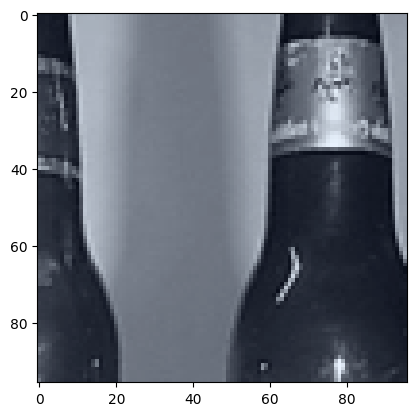

In [56]:
%matplotlib inline
plt.imshow(einops.rearrange(lc[0,...], 'c h w -> h w c'))

In [29]:
dl0['collated_masks'].shape

torch.Size([128, 196])

In [30]:
dl0['n_masked_patches']

tensor([3723])